### One Hot Encoding->
done for Nominal data (the data which isn't inter-connected (no relation))

eg:colors
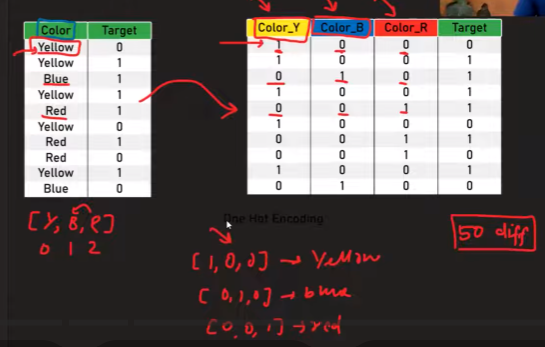

## Dummy Variable Trap
the columns created after One hot encoding are called Dummy variables.
and we need to remove one of the column because of multi-collinearity problem
since we need only (n-1) column values to represent n-cols.
this is called Dummy variable trap.
![image.png](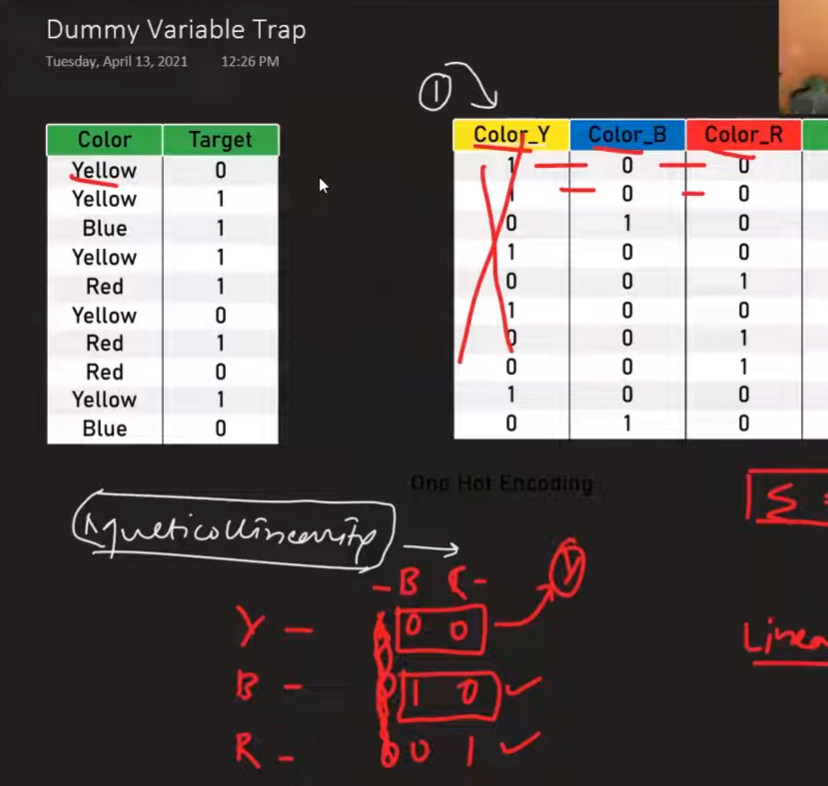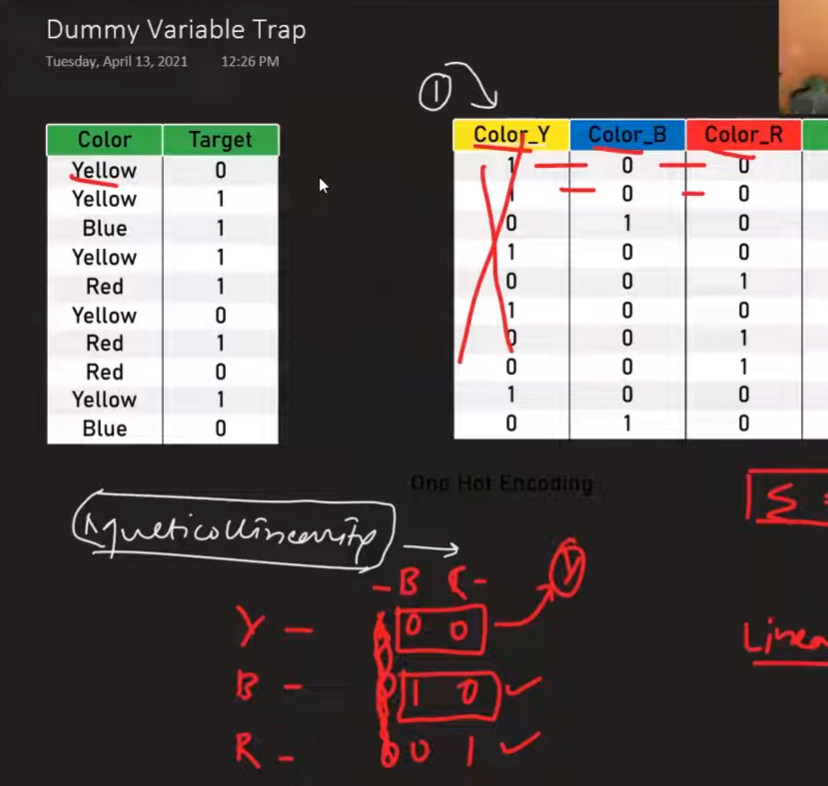)




### OHE using frequent variables-
in this we dont perform OHE on all the columns rather we perform it on the most  frequently used columns (for eg: cars brands)

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv("cars.csv")

In [ ]:
df.head(6)

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000
5,Hyundai,45000,Petrol,First Owner,440000


In [ ]:
df['brand'].value_counts()

27

In [ ]:
df['brand'].nunique()

32

In [ ]:
df['fuel'].value_counts()

,count
fuel,
Diesel,4402
Petrol,3631
CNG,57
LPG,38


In [ ]:
df['owner'].value_counts()

,count
owner,
First Owner,5289
Second Owner,2105
Third Owner,555
Fourth & Above Owner,174
Test Drive Car,5


### OHE using Pandas
this will divide columns- fuel will be divided into 4 further columns i.e
 `fuel_diesel`, ` fuel_petrol`, ` fuel_CNG `, `fuel_LPG`

whereas,

 Owner will be divided into 5 futher columns i.e
 `First Owner`,`Second Owner`,`Third Owner`,`Fourth & Above Owner`	,`Test Drive Car`

In [ ]:
pd.get_dummies(df,columns=['fuel','owner'])


,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,False,True,False,False,True,False,False,False,False
1,Skoda,120000,370000,False,True,False,False,False,False,True,False,False
2,Honda,140000,158000,False,False,False,True,False,False,False,False,True
3,Hyundai,127000,225000,False,True,False,False,True,False,False,False,False
4,Maruti,120000,130000,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,False,True,True,False,False,False,False
8124,Hyundai,119000,135000,False,True,False,False,False,True,False,False,False
8125,Maruti,120000,382000,False,True,False,False,True,False,False,False,False
8126,Tata,25000,290000,False,True,False,False,True,False,False,False,False


### K-1 OHE
in this we simply remove the first column to prevent multi-collinearity form our data
it will remove first column of owner i.e `owner_First_owner` as well as 1st column of fuel
`fuel_CNG`

In [ ]:
pd.get_dummies(df,columns=['fuel','owner'],drop_first=True)


,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,True,False,False,False,False,False,False
1,Skoda,120000,370000,True,False,False,False,True,False,False
2,Honda,140000,158000,False,False,True,False,False,False,True
3,Hyundai,127000,225000,True,False,False,False,False,False,False
4,Maruti,120000,130000,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,True,False,False,False,False
8124,Hyundai,119000,135000,True,False,False,True,False,False,False
8125,Maruti,120000,382000,True,False,False,False,False,False,False
8126,Tata,25000,290000,True,False,False,False,False,False,False


### OHE using sklearn
since `pandas` doesn't have memory to store at which position it has kept which column name that's we need to shift to `sklearn library`

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(df.iloc[:,0:4],df.iloc[:,-1],test_size=0.2,random_state=0)


In [ ]:
X_train.head()

,brand,km_driven,fuel,owner
3042,Hyundai,60000,LPG,First Owner
1520,Tata,150000,Diesel,Third Owner
2611,Hyundai,110000,Diesel,Second Owner
3544,Mahindra,28000,Diesel,Second Owner
4138,Maruti,15000,Petrol,First Owner


In [ ]:
y_train.head()

,selling_price
3042,375000
1520,150000
2611,459999
3544,1050000
4138,700000


In [ ]:
X_test.head()

,brand,km_driven,fuel,owner
3558,Hyundai,40000,Diesel,First Owner
233,Mahindra,70000,Diesel,First Owner
7952,Maruti,5000,Petrol,First Owner
572,Maruti,120000,Petrol,Third Owner
6960,Lexus,20000,Petrol,First Owner


In [ ]:
y_test.head()

,selling_price
3558,345000
233,900000
7952,475000
572,120000
6960,5150000


## till this point of time our dataset has been trained well and we just have to perfom OHE to change the OG dataset.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
ohe = OneHotEncoder(drop='first', dtype=np.int32)
#remvoing first column as well
#creating object of this class i.e OneHotEncoder

#### now, we will separate fuel and owner cols and apply OHE on `fuel` and `owner` columns only and then we merge `fuel & owner` with `brand & km_driven`

In [ ]:
X_train_new = ohe.fit_transform(X_train[['fuel','owner']]).toarray()


#this contains 9 cols= 5 from owner and 4 from fuel

In [ ]:
X_test_new = ohe.transform(X_test[['fuel','owner']]).toarray()

In [ ]:
X_test_new

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.]])

In [ ]:
np.hstack((X_train[['brand','km_driven']].values,X_train_new)).shape

(6502, 11)

### OHE with top Categories- most frequently used ones

In [ ]:
counts= df['brand'].value_counts()

In [ ]:
df['brand'].nunique()
threshold=100  # if a brand has cars less than 100 it will be categorized to others section

In [ ]:
repl = counts[counts <= threshold].index

In [ ]:
pd.get_dummies(df['brand'].replace(repl,'uncommon')).sample(20)

,BMW,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Renault,Skoda,Tata,Toyota,Volkswagen,uncommon
7652,False,False,False,False,False,False,True,False,False,False,False,False,False
1271,False,False,False,False,False,True,False,False,False,False,False,False,False
5998,False,False,False,False,False,False,True,False,False,False,False,False,False
4403,False,False,True,False,False,False,False,False,False,False,False,False,False
1166,False,False,False,False,False,False,True,False,False,False,False,False,False
4276,False,False,False,False,False,False,True,False,False,False,False,False,False
5069,False,False,False,False,False,False,False,False,False,False,False,True,False
5238,False,False,False,False,False,False,False,False,False,True,False,False,False
5217,False,False,False,False,False,False,False,False,False,True,False,False,False
6427,False,False,False,False,False,False,True,False,False,False,False,False,False
